In [6]:
import pandas as pd
import os
from sklearn.metrics import confusion_matrix

# Input and output paths
input_dir = "./gpt and llama"
output_csv = "./model_confusion_matrix_summary.csv"

# save results in a list of dictionaries
conf_results = []
    
# Process each CSV file in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith(".csv"):
        model_name = os.path.splitext(filename)[0]
        filepath = os.path.join(input_dir, filename)
        df = pd.read_csv(filepath)

        y_true = (df["score"] >= 0.5).astype(int) # a threshold of 0.5 for binary classification
        y_pred = (df["output_score"]).astype(int) 

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        conf_results.append({
            "model_name": model_name,
            "TP": tp,
            "FN": fn,
            "FP": fp,
            "TN": tn
        })

# Save the summary results to a new CSV file
summary_df = pd.DataFrame(conf_results)
summary_df.to_csv(output_csv, index=False)
print(f"results saved as {output_csv}")

results saved as ./model_confusion_matrix_summary.csv


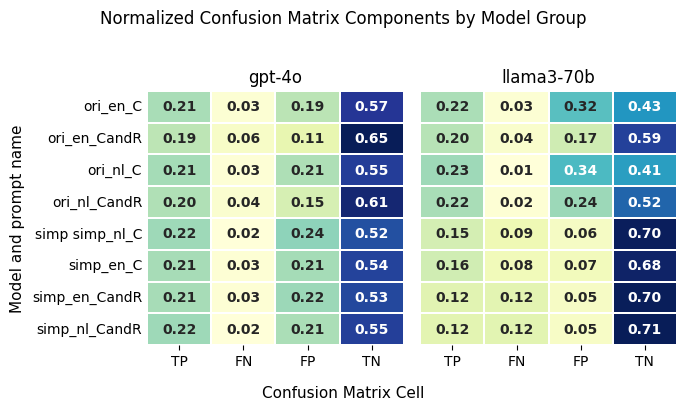

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load data
csv_path = "./model_confusion_matrix_summary.csv"
df = pd.read_csv(csv_path)

# Get the prompt and model name, and order by model and prompt
tmp = df["model_name"].str.split(r"\s+", n=1, expand=True)
df["model"] = tmp[0]
df["prompt"] = tmp[1]
df = df.sort_values(by=["model", "prompt"], kind="stable")

# Normalise the confusion matrix values to get proportions
cm_cols = ["TP", "FN", "FP", "TN"]
df_norm = df[cm_cols].div(df[cm_cols].sum(axis=1), axis=0)

def build_group_matrix(df_all, df_norm_all, model_name):
    sub_df = df_all[df_all["model"] == model_name]
    sub_norm = df_norm_all.loc[sub_df.index]
    row_labels = sub_df["prompt"].tolist()
    return sub_norm, row_labels

# Organise the data for the two models into separate matrices for plotting
model_left = df["model"].unique()[0]    # gpt-4o
model_right = df["model"].unique()[1]   # llama3-70b
plot_df_L, row_labels_L = build_group_matrix(df, df_norm, model_left)
plot_df_R, row_labels_R = build_group_matrix(df, df_norm, model_right)

# ===== Plotting =====
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

fig, axes = plt.subplots(1, 2, figsize=(7, 4))

# left part
axL = sns.heatmap(
    plot_df_L, annot=True, fmt=".2f",
    cmap="YlGnBu", linewidths=0.3,
    cbar=False, mask=plot_df_L.isna(), ax=axes[0],
    annot_kws={"fontsize": 10, "weight": "bold"}
)
axL.set_yticklabels(row_labels_L, rotation=0)
axL.set_title(model_left, pad=6)
axL.set_ylabel("Model and prompt name", labelpad=5)
axL.tick_params(axis='y', length=0)  

# right part
axR = sns.heatmap(
    plot_df_R, annot=True, fmt=".2f",
    cmap="YlGnBu", linewidths=0.3,
    cbar=False, mask=plot_df_R.isna(), ax=axes[1],
    annot_kws={"fontsize": 10, "weight": "bold"}
)
axR.set_yticklabels([])  # remove y tick labels for the right plot
axR.set_title(model_right, pad=6)
axR.set_ylabel("")       # remove y label for the right plot
axR.tick_params(axis='y', length=0)

# Remove x labels for both plots
axL.set_xlabel("")
axR.set_xlabel("")

# Add a common x-axis label at the bottom center of the figure, and top caption
fig.text(0.5, 0.02, "Confusion Matrix Cell", ha="center", va="center", fontsize=11)
fig.suptitle("Normalized Confusion Matrix Components by Model Group", fontsize=12, y=0.98)

plt.tight_layout(rect=[0, 0.04, 1, 0.96])

# save the figure as a PDF file
out_pdf = "./grouped_confusion_matrix.pdf"
plt.savefig(out_pdf, format="pdf", bbox_inches="tight")
plt.show()